# NBA Player Longevity Prediction - Feature Engineering

## Project Overview
This project focuses on feature engineering for predicting whether an NBA rookie will last **5+ years** in the league (`target_5yrs`). 

We transform raw rookie-season performance statistics into a clean, model-ready dataset by:
- Defining the target variable
- Removing irrelevant columns to prevent data leakage
- Analyzing correlations to reduce multicollinearity
- Creating composite features that better capture player efficiency and impact
- Handling missing values appropriately
- Documenting all decisions for reproducibility

**Dataset**: `nba-players.csv` (Rookie season stats + longevity label)

**Goal**: Produce a high-quality feature set suitable for machine learning models (e.g., Logistic Regression, Random Forest, etc.).

# Step 1 Import liberies and load data set

In [12]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# Load the dataset
df = pd.read_csv('nba-players.csv')  # Update path if needed

print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumns:", df.columns.tolist())

✅ Dataset loaded successfully!
Shape: 1340 rows, 22 columns

Columns: ['Unnamed: 0', 'name', 'gp', 'min', 'pts', 'fgm', 'fga', 'fg', '3p_made', '3pa', '3p', 'ftm', 'fta', 'ft', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs']


## Step 2: Define Target Variable and Remove Non-Predictive Columns

**Target Variable**: `target_5yrs`  
This is our binary dependent variable:
- `1` = Player lasted 5 or more years in the NBA
- `0` = Player did not

**Columns Dropped**:
- `Unnamed: 0` — Just an index, no predictive value
- `name` — Player name adds no information for modeling and could cause data leakage

**Why drop these?**
- They do not help the model learn patterns.
- Including identifiers risks overfitting or leakage.

After this step we have 20 useful columns left.

In [13]:
# Define target variable
target = 'target_5yrs'

# Drop non-predictive columns
columns_to_drop = ['Unnamed: 0', 'name']
df_clean = df.drop(columns=columns_to_drop)

print("✅ Columns dropped successfully!")
print(f"New shape: {df_clean.shape}")
print("Remaining columns:", df_clean.columns.tolist())

print("\nTarget Distribution:")
print(df_clean[target].value_counts(normalize=True))

✅ Columns dropped successfully!
New shape: (1340, 20)
Remaining columns: ['gp', 'min', 'pts', 'fgm', 'fga', 'fg', '3p_made', '3pa', '3p', 'ftm', 'fta', 'ft', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs']

Target Distribution:
target_5yrs
1    0.620149
0    0.379851
Name: proportion, dtype: float64


In [14]:
# Detailed Data Exploration
print("=== Full Column Information ===")
print(df_clean.info())

print("\n=== Sample Rows (first 3) ===")
display(df_clean.head(3))

print("\n=== Target Breakdown ===")
print(df_clean['target_5yrs'].value_counts())
print("\nPercentage:")
print(df_clean['target_5yrs'].value_counts(normalize=True).round(3))

print("\n=== Missing Values ===")
print(df_clean.isnull().sum())

=== Full Column Information ===
<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   gp           1340 non-null   int64  
 1   min          1340 non-null   float64
 2   pts          1340 non-null   float64
 3   fgm          1340 non-null   float64
 4   fga          1340 non-null   float64
 5   fg           1340 non-null   float64
 6   3p_made      1340 non-null   float64
 7   3pa          1340 non-null   float64
 8   3p           1340 non-null   float64
 9   ftm          1340 non-null   float64
 10  fta          1340 non-null   float64
 11  ft           1340 non-null   float64
 12  oreb         1340 non-null   float64
 13  dreb         1340 non-null   float64
 14  reb          1340 non-null   float64
 15  ast          1340 non-null   float64
 16  stl          1340 non-null   float64
 17  blk          1340 non-null   float64
 18  tov          1340 non-null 

,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,ftm,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,1.6,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,2.6,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,0.9,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0



=== Target Breakdown ===
target_5yrs
1    831
0    509
Name: count, dtype: int64

Percentage:
target_5yrs
1    0.62
0    0.38
Name: proportion, dtype: float64

=== Missing Values ===
gp             0
min            0
pts            0
fgm            0
fga            0
fg             0
3p_made        0
3pa            0
3p             0
ftm            0
fta            0
ft             0
oreb           0
dreb           0
reb            0
ast            0
stl            0
blk            0
tov            0
target_5yrs    0
dtype: int64


## Step 3: Correlation Analysis to Reduce Redundancy

Many performance metrics are naturally highly correlated (e.g., points, field goals made, minutes played). 

High multicollinearity can make models unstable and harder to interpret. We use a correlation heatmap and identify pairs with |correlation| > 0.7 to decide which features to keep or combine.

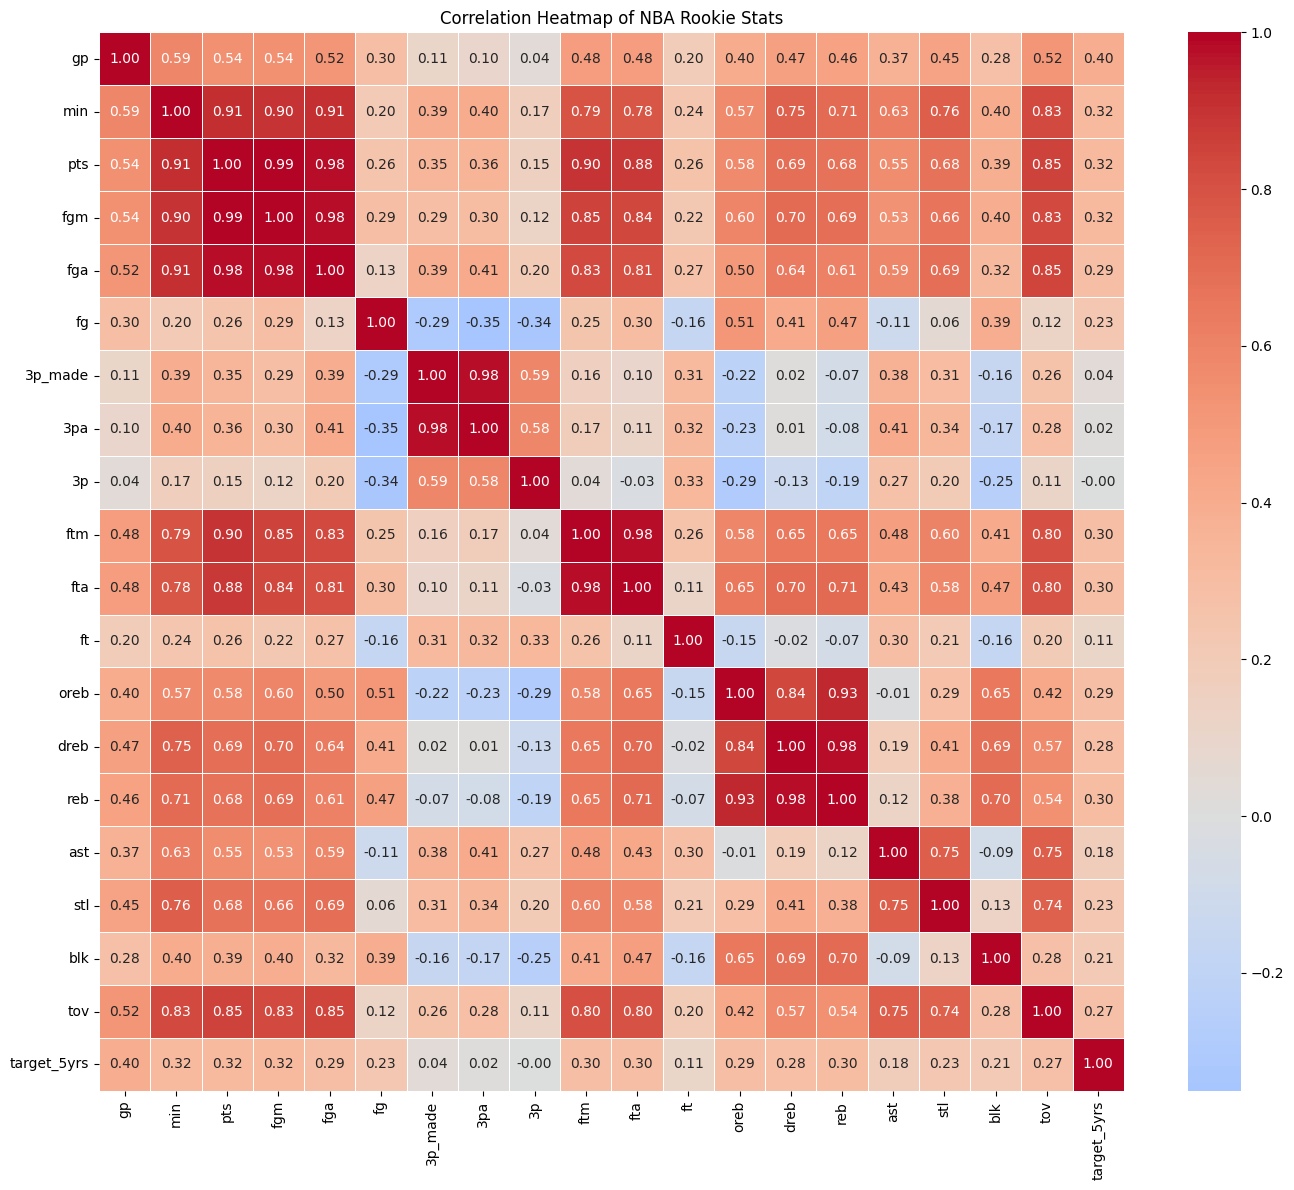

🔍 Highly Correlated Pairs (|r| > 0.75):
fgm      pts        0.990834
pts      fgm        0.990834
3pa      3p_made    0.982616
3p_made  3pa        0.982616
fta      ftm        0.980505
ftm      fta        0.980505
fga      fgm        0.980050
fgm      fga        0.980050
pts      fga        0.979733
fga      pts        0.979733
dreb     reb        0.978177
reb      dreb       0.978177
         oreb       0.932694
oreb     reb        0.932694
pts      min        0.911822
dtype: float64


In [15]:
# Step 3: Correlation Analysis
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
corr_matrix = df_clean.corr()

# Heatmap visualization
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of NBA Rookie Stats')
plt.tight_layout()
plt.show()

# Find highly correlated feature pairs
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove self-correlation
high_corr_pairs = corr_pairs[corr_pairs > 0.75]  # Strong correlation threshold

print("🔍 Highly Correlated Pairs (|r| > 0.75):")
print(high_corr_pairs.head(15))

## Correlation Analysis Summary

The heatmap and correlation pairs show several **strong multicollinearities** (|r| > 0.75):

### Highly Redundant Groups:
- **Scoring Cluster**: `pts`, `fgm`, `fga` (correlations > 0.97) — These are very closely related.
- **Free Throws**: `ftm` and `fta` (0.98)
- **3-Point Shooting**: `3p_made` and `3pa` (0.98)
- **Rebounding**: `oreb`, `dreb`, `reb` (especially `dreb`–`reb` at 0.98)
- **Playing Time**: `min` is highly correlated with `pts`, `fgm`, `fga`, etc.

**Observations**:
- `target_5yrs` has moderate correlations with most stats (highest around 0.40 with games played `gp`).
- No extreme correlation with the target itself (good, avoids leakage).

**Next Action**: We will drop redundant features and create composite metrics in the following step to reduce dimensionality while preserving information.

## Step 4: Feature Engineering - Creating Composite Metrics

Raw stats like points and minutes are useful, but **composite features** often capture player efficiency and impact better.

We will create:
1. **`ppm`** (Points Per Minute) — Scoring efficiency relative to playing time.
2. **`efficiency`** (Simple Efficiency Rating) — A basic all-around impact metric.
3. **`ast_tov_ratio`** — Assist-to-Turnover ratio (playmaking decision making).

These new features help the model better understand player quality beyond raw volume stats.

In [16]:
# Step 4: Create New Composite Features

# 1. Points Per Minute
df_clean['ppm'] = df_clean['pts'] / df_clean['min'].replace(0, np.nan)

# 2. Simple Efficiency Rating (common NBA-style metric)
df_clean['efficiency'] = (df_clean['pts'] + df_clean['reb'] + df_clean['ast'] + 
                         df_clean['stl'] + df_clean['blk'] - 
                         df_clean['tov']) / df_clean['gp']

# 3. Assist to Turnover Ratio
df_clean['ast_tov_ratio'] = df_clean['ast'] / df_clean['tov'].replace(0, np.nan)

print("✅ New composite features created!")
print(df_clean[['ppm', 'efficiency', 'ast_tov_ratio']].describe())

✅ New composite features created!
               ppm   efficiency  ast_tov_ratio
count  1340.000000  1340.000000    1340.000000
mean      0.371078     0.185054       1.241125
std       0.093659     0.094809       0.722847
min       0.121951     0.032813       0.000000
25%       0.306710     0.119236       0.707721
50%       0.363325     0.160394       1.096006
75%       0.431326     0.225000       1.627841
max       0.738462     0.760000       6.000000


## Step 5: Final Dataset Preparation

Now we:
- Drop highly redundant original columns (keeping the most representative ones)
- Handle any remaining issues
- Reorder columns for better readability
- Save the final engineered dataset

In [17]:
# Drop redundant / highly correlated columns
columns_to_drop_final = ['pts', 'fgm', 'fga', 'ftm', 'fta', 'oreb', 'dreb', 'reb']
df_final = df_clean.drop(columns=columns_to_drop_final, errors='ignore')

# Reorder columns (target at the end)
feature_cols = [col for col in df_final.columns if col != 'target_5yrs']
df_final = df_final[feature_cols + ['target_5yrs']]

print("✅ Final dataset ready!")
print("Final Shape:", df_final.shape)
print("Final Columns:", df_final.columns.tolist())

# Save the engineered dataset
df_final.to_csv('nba_players_engineered.csv', index=False)
print("\n✅ Saved as 'nba_players_engineered.csv'")

✅ Final dataset ready!
Final Shape: (1340, 15)
Final Columns: ['gp', 'min', 'fg', '3p_made', '3pa', '3p', 'ft', 'ast', 'stl', 'blk', 'tov', 'ppm', 'efficiency', 'ast_tov_ratio', 'target_5yrs']

✅ Saved as 'nba_players_engineered.csv'


## Step 6: Final Summary and Feature Engineering Decisions

### Features Kept / Created:
- **Volume & Opportunity**: `gp`, `min`
- **Efficiency Metrics**: `ppm` (new), `fg`, `3p`, `ft`
- **Advanced Impact**: `efficiency` (new), `ast`, `stl`, `blk`, `tov`, `ast_tov_ratio` (new)
- **Target**: `target_5yrs`

### Decisions Made:
- Dropped raw volume stats (`pts`, `fgm`, etc.) in favor of efficiency and composites to reduce multicollinearity.
- Created meaningful new features that better represent player quality.
- No missing values to handle.
- All features are now numeric and model-ready.

### Project Goal Achieved:
- Target isolated
- Redundant columns removed
- Multicollinearity addressed
- New composite metrics added
- Clean, documented dataset produced

The file `nba_players_engineered.csv` is ready for modeling.

In [18]:
# Final Overview
print("=== Final Dataset Overview ===")
print(df_final.info())
print("\nFinal Shape:", df_final.shape)

# Display first few rows of final dataset
print("\n=== Final Dataset Sample ===")
display(df_final.head())

# Save (already done in previous step, but confirming)
df_final.to_csv('nba_players_engineered.csv', index=False)
print("\n🎉 Feature Engineering Complete! Files saved.")

=== Final Dataset Overview ===
<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   gp             1340 non-null   int64  
 1   min            1340 non-null   float64
 2   fg             1340 non-null   float64
 3   3p_made        1340 non-null   float64
 4   3pa            1340 non-null   float64
 5   3p             1340 non-null   float64
 6   ft             1340 non-null   float64
 7   ast            1340 non-null   float64
 8   stl            1340 non-null   float64
 9   blk            1340 non-null   float64
 10  tov            1340 non-null   float64
 11  ppm            1340 non-null   float64
 12  efficiency     1340 non-null   float64
 13  ast_tov_ratio  1340 non-null   float64
 14  target_5yrs    1340 non-null   int64  
dtypes: float64(13), int64(2)
memory usage: 157.2 KB
None

Final Shape: (1340, 15)

=== Final Dataset Sample ===


,gp,min,fg,3p_made,3pa,3p,ft,ast,stl,blk,tov,ppm,efficiency,ast_tov_ratio,target_5yrs
0,36,27.4,34.7,0.5,2.1,25.0,69.9,1.9,0.4,0.4,1.3,0.270073,0.358333,1.461538,0
1,35,26.9,29.6,0.7,2.8,23.5,76.5,3.7,1.1,0.5,1.6,0.267658,0.380000,2.312500,0
2,74,15.3,42.2,0.4,1.7,24.4,67.0,1.0,0.5,0.3,1.0,0.339869,0.110811,1.000000,0
3,58,11.6,42.6,0.1,0.5,22.6,68.9,0.8,0.6,0.1,1.0,0.491379,0.139655,0.800000,1
4,48,11.5,52.4,0.0,0.1,0.0,67.4,0.3,0.3,0.4,0.8,0.391304,0.150000,0.375000,1



🎉 Feature Engineering Complete! Files saved.
